# 歪-励磁磁場曲線に関する調査  
作成日：2026年09月02日  
作成者：上杉 健太  

In [1]:
# conf
project_name = "260902_歪-励磁磁場曲線"

C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\600751276.py:85: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\600751276.py:85: UserWarning: Glyph 31639 (\N{CJK UNIFIED IDEOGRAPH-7B97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\600751276.py:85: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\600751276.py:85: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\600751276.py:85: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\600751276.py:85: UserWarning: Glyph 26178 (\N{CJK 

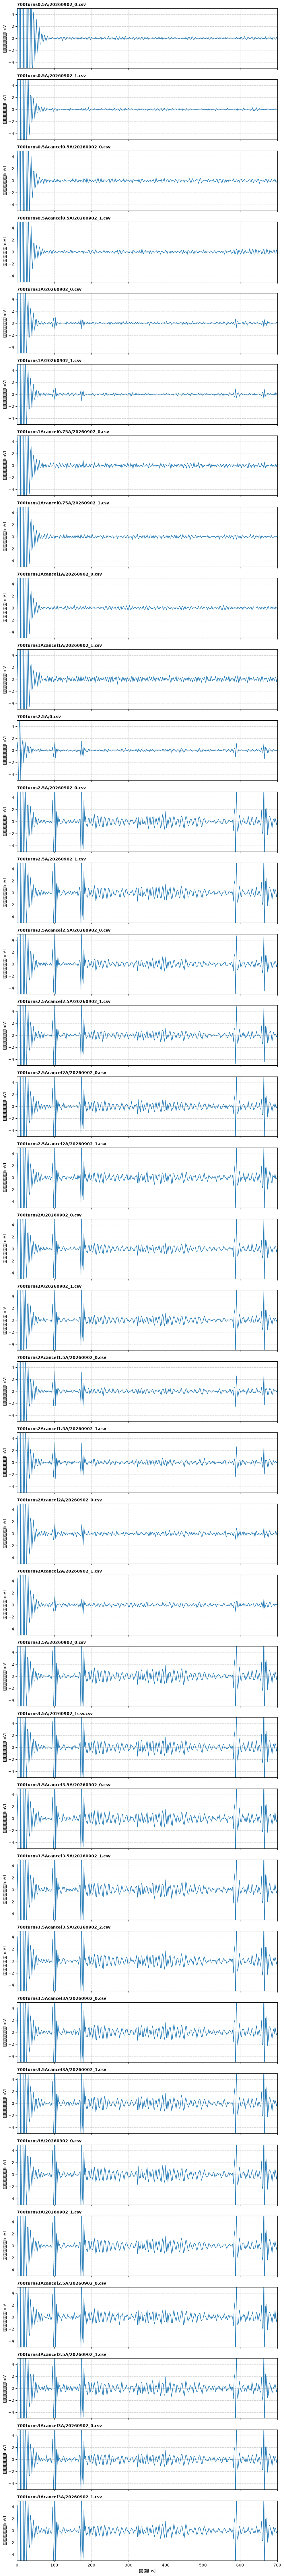

計 36 件のグラフを作成し、"results\260902_歪-励磁磁場曲線\comparison_plot.png" に保存しました。


In [2]:
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# 日本語フォントの設定 (環境に応じて japanize_matplotlib を併用してください)
try:
  import japanize_matplotlib
except ImportError:
  # 文字化けする場合は環境にある日本語フォントを指定（例: MS Gothic, IPAexGothic など）
  plt.rcParams['font.family'] = 'sans-serif'

# 1. 対象となるCSVファイルのパスを取得
target_pattern = f'source/{project_name}/**/*.csv'
csv_files = sorted(glob.glob(target_pattern, recursive=True))

if not csv_files:
  print('対象のCSVファイルが見つかりませんでした。パスを確認してください。')
else:
  num_files = len(csv_files)

  # 2. グラフの描画領域（縦並び）を作成
  fig, axes = plt.subplots(
      nrows=num_files, ncols=1, figsize=(10, 2.5 * num_files), sharex=True
  )

  # ファイルが1つだけの場合の型合わせ
  if num_files == 1:
    axes = [axes]

  x_col = '時間[μs]'
  y_col = ' 加算平均値[V]'  # ※元のデータに合わせて先頭のスペースを維持しています

  # 3. 各CSVファイルを読み込んで描画
  for ax, file_path in zip(axes, csv_files):
    # 日本語を含むCSVに対応（utf-8 で失敗した場合は cp932/Shift-JIS で再試行）
    try:
      df = pd.read_csv(file_path, encoding='ms932')
    except (UnicodeDecodeError, pd.errors.ParserError):
      df = pd.read_csv(file_path, encoding='cp932')

    # カラムの存在確認をしてプロット
    if x_col in df.columns and y_col in df.columns:
      folder_and_file = '/'.join(Path(file_path).parts[-2:])

      # [変更点] Vを1000倍してmVに変換
      y_data_mv = df[y_col] * 1000

      ax.plot(
          df[x_col],
          y_data_mv,
          color='tab:blue',
          linewidth=1.2,
          label=folder_and_file,
      )

      ax.set_title(folder_and_file, fontsize=10, loc='left', fontweight='bold')
      ax.set_ylabel('加算平均値[mV]', fontsize=9)  # 単位表記をmVに変更

      # [変更点] 軸の表示範囲を設定
      ax.set_xlim(0, 700)  # X軸: 0 〜 700
      ax.set_ylim(-5, 5)  # Y軸: -5mV 〜 5mV

      ax.grid(True, linestyle='--', alpha=0.6)
    else:
      ax.text(
          0.5,
          0.5,
          f'指定カラムが見つかりません:\n{file_path}',
          ha='center',
          va='center',
          transform=ax.transAxes,
      )

  # 一番下のサブプロットにのみ横軸のラベルを設定
  axes[-1].set_xlabel(x_col, fontsize=10)

  # [変更点] 保存先フォルダが存在しない場合は自動作成
  output_dir = Path(f'./results/{project_name}')
  output_dir.mkdir(parents=True, exist_ok=True)

  output_filename = output_dir / 'comparison_plot.png'

  # レイアウト調整と保存
  plt.tight_layout()
  plt.savefig(output_filename, dpi=300, bbox_inches='tight')
  plt.show()

  print(
      f'計 {num_files} 件のグラフを作成し、"{output_filename}" に保存しました。'
  )

C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\3138381346.py:115: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\3138381346.py:115: UserWarning: Glyph 31639 (\N{CJK UNIFIED IDEOGRAPH-7B97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\3138381346.py:115: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\3138381346.py:115: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\3138381346.py:115: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\3138381346.py:115: UserWarning: Glyph 26

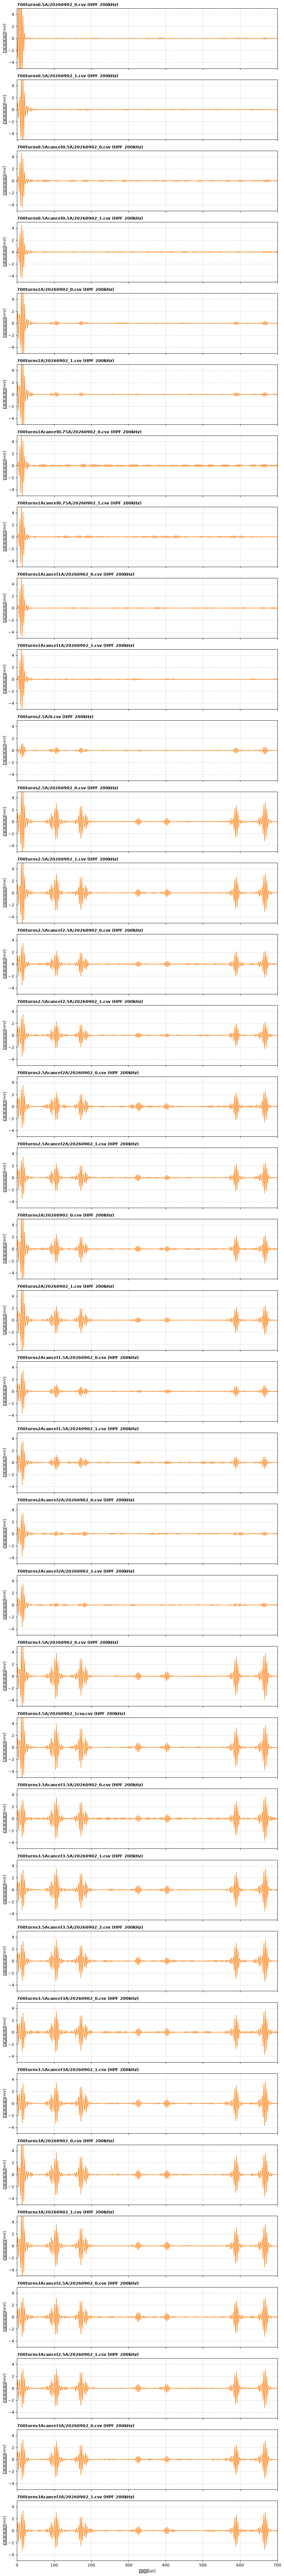

計 36 件のフィルタ適用済グラフを作成し、"results\260902_歪-励磁磁場曲線\comparison_plot_hpf200kHz.png" に保存しました。


In [3]:
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

# 日本語フォントの設定
try:
  import japanize_matplotlib
except ImportError:
  plt.rcParams['font.family'] = 'sans-serif'

# 1. ハイパスフィルタの条件設定
CUTOFF_HZ = 200e3  # カットオフ周波数: 200 kHz (200,000 Hz)
FILTER_ORDER = 4  # フィルタの次数

# 対象ファイルの取得
target_pattern = f'source/{project_name}/**/*.csv'
csv_files = sorted(glob.glob(target_pattern, recursive=True))

if not csv_files:
  print('対象のCSVファイルが見つかりませんでした。')
else:
  num_files = len(csv_files)

  # 描画領域の作成
  fig, axes = plt.subplots(
      nrows=num_files, ncols=1, figsize=(10, 2.5 * num_files), sharex=True
  )

  if num_files == 1:
    axes = [axes]

  x_col = '時間[μs]'
  y_col = ' 加算平均値[V]'

  for ax, file_path in zip(axes, csv_files):
    try:
      df = pd.read_csv(file_path, encoding='ms932')
    except (UnicodeDecodeError, pd.errors.ParserError):
      df = pd.read_csv(file_path, encoding='cp932')

    if x_col in df.columns and y_col in df.columns:
      folder_and_file = '/'.join(Path(file_path).parts[-2:])

      time_us = df[x_col].values
      y_v = df[y_col].values

      # 2. 時間データからサンプリング周波数(fs)を自動算出 [Hz]
      dt_us = np.mean(np.diff(time_us))  # サンプリング周期 [μs]
      fs = 1e6 / dt_us  # サンプリング周波数 [Hz]
      nyq = 0.5 * fs  # ナイキスト周波数

      # サンプリング周波数がナイキスト定理を満たしているか判定
      if CUTOFF_HZ >= nyq:
        ax.text(
            0.5,
            0.5,
            f'サンプリング周波数が不足しています\n(fs={fs/1e3:.1f}kHz < 400kHz)',
            ha='center',
            va='center',
            transform=ax.transAxes,
            color='red',
        )
        continue

      # 3. 200kHz ハイパスフィルタの設計と適用
      normal_cutoff = CUTOFF_HZ / nyq
      b, a = butter(FILTER_ORDER, normal_cutoff, btype='highpass')

      # mV単位へ変換後にフィルタを計算（filtfiltで波形の時間ズレを防止）
      y_mv = y_v * 1000
      y_filtered = filtfilt(b, a, y_mv)

      # 描画
      ax.plot(
          time_us,
          y_filtered,
          color='tab:orange',
          linewidth=1.2,
          label=folder_and_file,
      )

      ax.set_title(
          f'{folder_and_file} (HPF 200kHz)',
          fontsize=10,
          loc='left',
          fontweight='bold',
      )
      ax.set_ylabel('加算平均値[mV]', fontsize=9)

      # 軸範囲の指定
      ax.set_xlim(0, 700)
      ax.set_ylim(-5, 5)

      ax.grid(True, linestyle='--', alpha=0.6)
    else:
      ax.text(
          0.5,
          0.5,
          f'指定カラムが見つかりません:\n{file_path}',
          ha='center',
          va='center',
          transform=ax.transAxes,
      )

  axes[-1].set_xlabel(x_col, fontsize=10)

  # 保存先フォルダとファイル名の設定 (フィルタ済とわかるファイル名に変更)
  output_dir = Path(f'./results/{project_name}')
  output_dir.mkdir(parents=True, exist_ok=True)
  output_filename = output_dir / 'comparison_plot_hpf200kHz.png'

  plt.tight_layout()
  plt.savefig(output_filename, dpi=300, bbox_inches='tight')
  plt.show()

  print(
      f'計 {num_files} 件のフィルタ適用済グラフを作成し、"{output_filename}" に保存しました。'
  )

## 各区間内の最小・最大値を見つけてVppを算出する

C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\4195061604.py:152: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig_raw.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\4195061604.py:152: UserWarning: Glyph 31639 (\N{CJK UNIFIED IDEOGRAPH-7B97}) missing from font(s) DejaVu Sans.
  fig_raw.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\4195061604.py:152: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig_raw.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\4195061604.py:152: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  fig_raw.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\4195061604.py:152: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  fig_raw.tight_layout()
C:\Users\kenta\AppData\Local\Temp\ipykernel_16812\4195061604.py:152: U

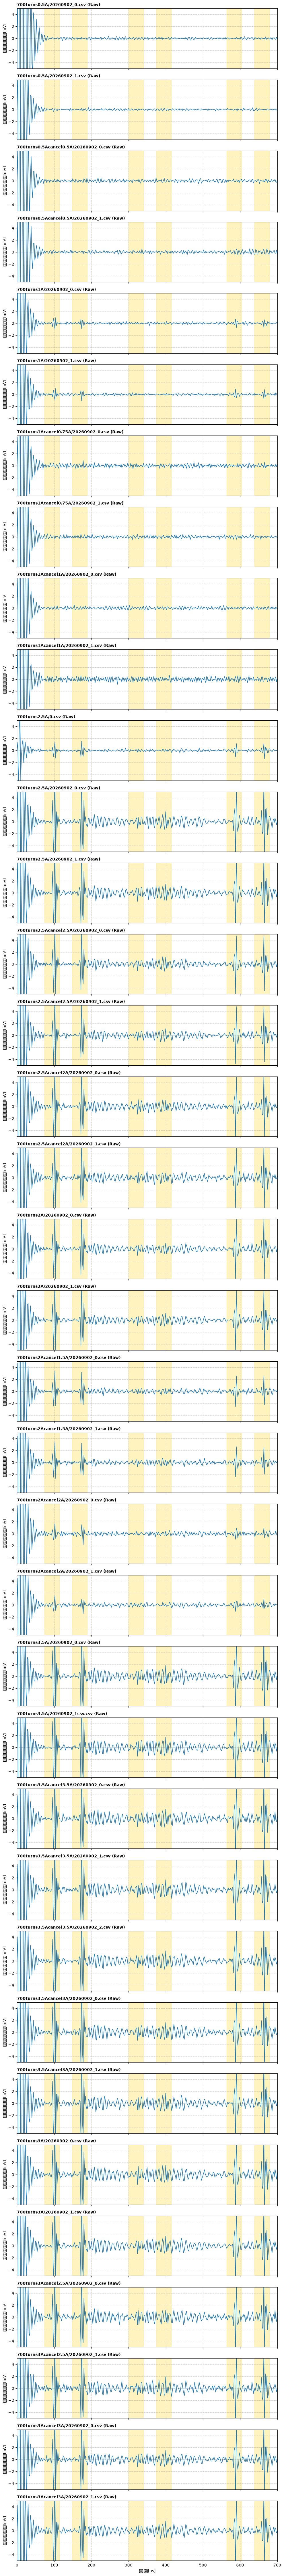

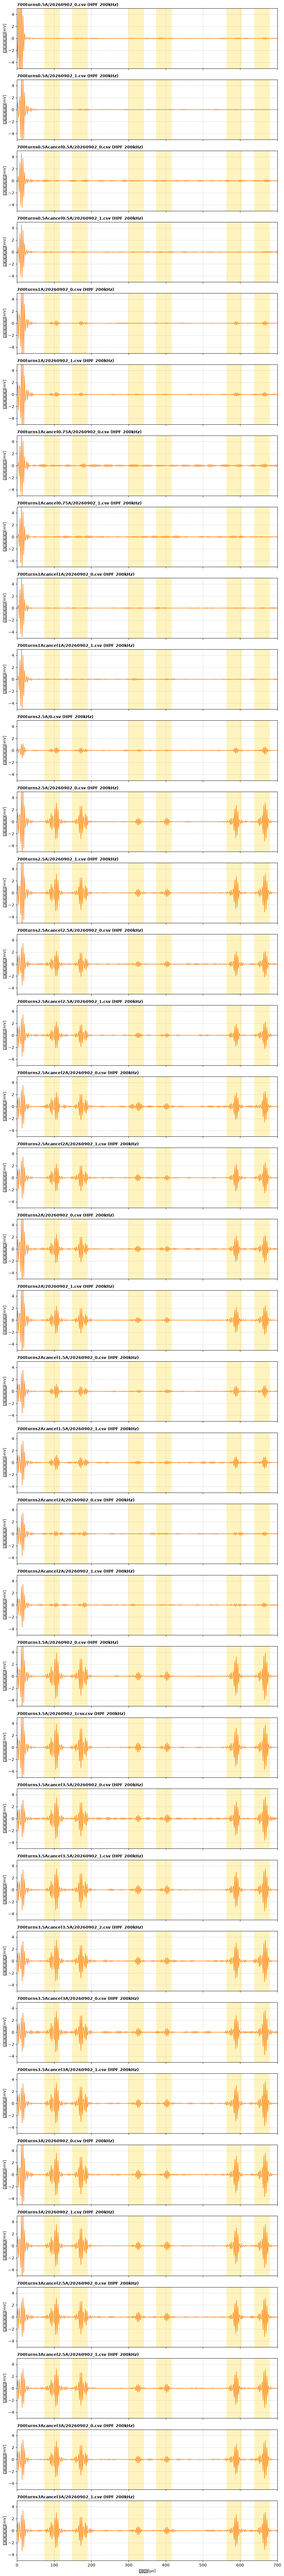

=== 処理完了 ===
1. 数値一覧データ : "results\260902_歪-励磁磁場曲線\p2p_summary.csv"
2. フィルタ前画像 : "results\260902_歪-励磁磁場曲線\comparison_raw_highlighted.png"
3. フィルタ後画像 : "results\260902_歪-励磁磁場曲線\comparison_hpf_highlighted.png"


,ファイル名,区間番号,時間帯[μs],Raw_最大値[mV],Raw_最小値[mV],Raw_P2P[mV],HPF_最大値[mV],HPF_最小値[mV],HPF_P2P[mV]
0,700turns0.5A/20260902_0.csv,1,74-114,0.534,-0.449,0.983,0.070483,-0.066065,0.136549
1,700turns0.5A/20260902_0.csv,2,149-189,0.240,-0.237,0.477,0.089874,-0.089936,0.179810
2,700turns0.5A/20260902_0.csv,3,300-340,0.206,-0.217,0.423,0.054666,-0.053130,0.107796
3,700turns0.5A/20260902_0.csv,4,375-415,0.255,-0.183,0.438,0.120283,-0.117798,0.238081
4,700turns0.5A/20260902_0.csv,5,564-604,0.239,-0.186,0.425,0.102466,-0.101386,0.203851
...,...,...,...,...,...,...,...,...,...
211,700turns3Acancel3A/20260902_1.csv,2,149-189,8.720,-5.196,13.916,2.304689,-2.532195,4.836884
212,700turns3Acancel3A/20260902_1.csv,3,300-340,0.852,-1.052,1.904,0.730672,-0.691983,1.422654
213,700turns3Acancel3A/20260902_1.csv,4,375-415,1.627,-1.289,2.916,0.604256,-0.607191,1.211447
214,700turns3Acancel3A/20260902_1.csv,5,564-604,6.213,-6.637,12.850,2.633753,-2.610534,5.244287


In [4]:
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

# 日本語フォントの設定
try:
  import japanize_matplotlib
except ImportError:
  plt.rcParams['font.family'] = 'sans-serif'

# 1. 抽出したい時間区間[μs]の定義
INTERVALS = {
    '1': (74, 114),
    '2': (149, 189),
    '3': (300, 340),
    '4': (375, 415),
    '5': (564, 604),
    '6': (639, 679),
}

# ハイパスフィルタの設定
CUTOFF_HZ = 200e3
FILTER_ORDER = 4

# 対象ファイルの取得
target_pattern = f'source/{project_name}/**/*.csv'
csv_files = sorted(glob.glob(target_pattern, recursive=True))

if not csv_files:
  print('対象のCSVファイルが見つかりませんでした。')
else:
  num_files = len(csv_files)
  summary_data = []  # 数値データを集積するリスト

  # フィルタ前用とフィルタ後用の2セットのキャンバスを作成
  fig_raw, axes_raw = plt.subplots(
      nrows=num_files, ncols=1, figsize=(10, 2.5 * num_files), sharex=True
  )
  fig_hpf, axes_hpf = plt.subplots(
      nrows=num_files, ncols=1, figsize=(10, 2.5 * num_files), sharex=True
  )

  if num_files == 1:
    axes_raw = [axes_raw]
    axes_hpf = [axes_hpf]

  x_col = '時間[μs]'
  y_col = ' 加算平均値[V]'

  for ax_r, ax_h, file_path in zip(axes_raw, axes_hpf, csv_files):
    try:
      df = pd.read_csv(file_path, encoding='ms932')
    except (UnicodeDecodeError, pd.errors.ParserError):
      df = pd.read_csv(file_path, encoding='cp932')

    if x_col in df.columns and y_col in df.columns:
      folder_and_file = '/'.join(Path(file_path).parts[-2:])
      time_us = df[x_col].values
      raw_mv = df[y_col].values * 1000  # V -> mV 変換

      # --- フィルタ処理 ---
      dt_us = np.mean(np.diff(time_us))
      fs = 1e6 / dt_us
      nyq = 0.5 * fs

      if CUTOFF_HZ < nyq:
        normal_cutoff = CUTOFF_HZ / nyq
        b, a = butter(FILTER_ORDER, normal_cutoff, btype='highpass')
        hpf_mv = filtfilt(b, a, raw_mv)
      else:
        hpf_mv = np.full_like(raw_mv, np.nan)

      # --- 1. 基本波形のプロット ---
      ax_r.plot(time_us, raw_mv, color='tab:blue', linewidth=1.2)
      ax_h.plot(time_us, hpf_mv, color='tab:orange', linewidth=1.2)

      # --- 2. 各区間の数値計算 ＆ ハイライト表示 ---
      for sec_num, (t_start, t_end) in INTERVALS.items():
        # 両方のグラフに黄色半透明でハイライト背景を付与
        for ax in [ax_r, ax_h]:
          ax.axvspan(t_start, t_end, color='gold', alpha=0.25)

        # 指定時間区間のデータを切り出し
        mask = (time_us >= t_start) & (time_us <= t_end)

        # フィルタ適用前 (Raw) の計算
        r_sub = raw_mv[mask]
        r_max = np.max(r_sub) if len(r_sub) > 0 else np.nan
        r_min = np.min(r_sub) if len(r_sub) > 0 else np.nan
        r_p2p = r_max - r_min if len(r_sub) > 0 else np.nan

        # フィルタ適用後 (HPF) の計算
        h_sub = hpf_mv[mask]
        if len(h_sub) > 0 and not np.isnan(h_sub).all():
          h_max = np.max(h_sub)
          h_min = np.min(h_sub)
          h_p2p = h_max - h_min
        else:
          h_max = h_min = h_p2p = np.nan

        # リストに数値を保持
        summary_data.append({
            'ファイル名': folder_and_file,
            '区間番号': sec_num,
            '時間帯[μs]': f'{t_start}-{t_end}',
            'Raw_最大値[mV]': r_max,
            'Raw_最小値[mV]': r_min,
            'Raw_P2P[mV]': r_p2p,
            'HPF_最大値[mV]': h_max,
            'HPF_最小値[mV]': h_min,
            'HPF_P2P[mV]': h_p2p,
        })

      # 各サブプロットの軸設定
      for ax, title_suffix in zip(
          [ax_r, ax_h], ['(Raw)', '(HPF 200kHz)']
      ):
        ax.set_title(
            f'{folder_and_file} {title_suffix}',
            fontsize=10,
            loc='left',
            fontweight='bold',
        )
        ax.set_ylabel('加算平均値[mV]', fontsize=9)
        ax.set_xlim(0, 700)
        ax.set_ylim(-5, 5)
        ax.grid(True, linestyle='--', alpha=0.6)

    else:
      for ax in [ax_r, ax_h]:
        ax.text(
            0.5,
            0.5,
            f'指定カラムが見つかりません:\n{file_path}',
            ha='center',
            va='center',
            transform=ax.transAxes,
        )

  # X軸ラベルの設定
  axes_raw[-1].set_xlabel(x_col, fontsize=10)
  axes_hpf[-1].set_xlabel(x_col, fontsize=10)

  # --- 3. 出力処理 ---
  output_dir = Path(f'./results/{project_name}')
  output_dir.mkdir(parents=True, exist_ok=True)

  # フィルタ前画像の保存
  fig_raw.tight_layout()
  fig_raw.savefig(
      output_dir / 'comparison_raw_highlighted.png',
      dpi=300,
      bbox_inches='tight',
  )

  # フィルタ後画像の保存
  fig_hpf.tight_layout()
  fig_hpf.savefig(
      output_dir / 'comparison_hpf_highlighted.png',
      dpi=300,
      bbox_inches='tight',
  )

  plt.show()  # フィルタ後画像を画面に表示

  # 4. 数値結果のDataFrame化とCSV出力
  df_summary = pd.DataFrame(summary_data)
  csv_path = output_dir / 'p2p_summary.csv'
  # 文字化け(Excel対応)防止のため utf-8-sig で保存
  df_summary.to_csv(csv_path, index=False, encoding='utf-8-sig')

  print('=== 処理完了 ===')
  print(f'1. 数値一覧データ : "{csv_path}"')
  print(
      f'2. フィルタ前画像 : "{output_dir / "comparison_raw_highlighted.png"}"'
  )
  print(
      f'3. フィルタ後画像 : "{output_dir / "comparison_hpf_highlighted.png"}"'
  )

# セル上で数値のテーブルを表示
df_summary

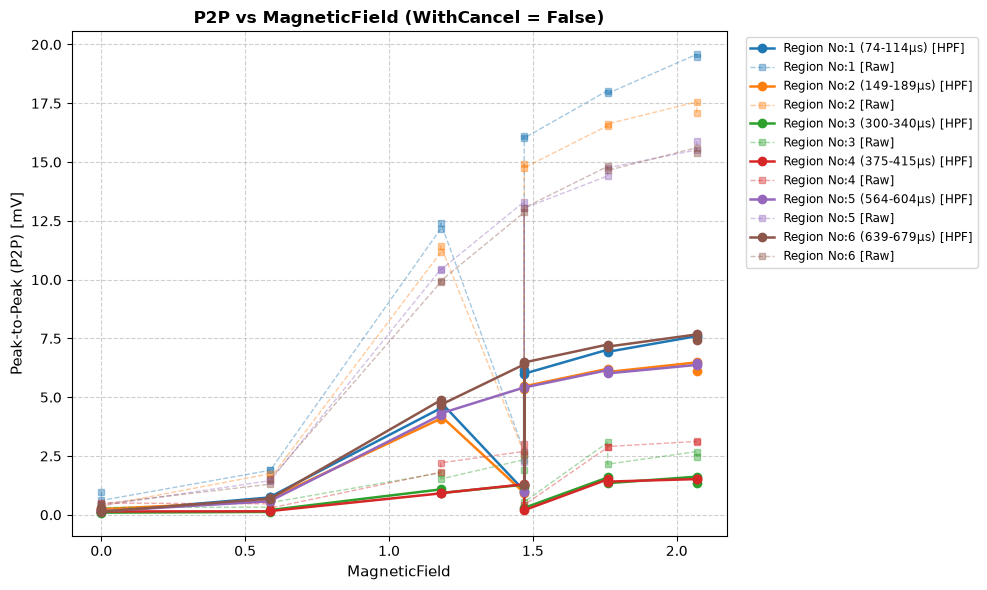

グラフを出力しました: "results\260902_歪-励磁磁場曲線\p2p_vs_magneticfield_WithCancel_False.png"


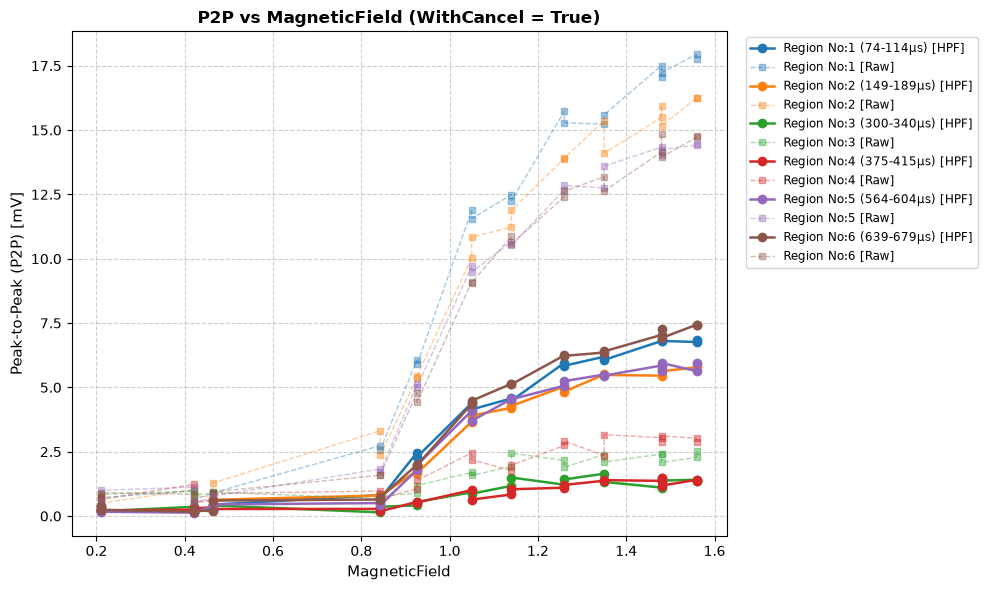

グラフを出力しました: "results\260902_歪-励磁磁場曲線\p2p_vs_magneticfield_WithCancel_True.png"


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# 日本語フォントの設定
try:
  import japanize_matplotlib
except ImportError:
  plt.rcParams['font.family'] = 'sans-serif'

# 1. FolderMaster.csv の読み込み
master_csv_path = f'./source/MasterData/FolderMaster.csv'
df_master = pd.read_csv(master_csv_path)

# WithCancel の文字列/数値表記をブール値 (True/False) に標準化
if df_master['WithCancel'].dtype == object:
  df_master['WithCancel'] = (
      df_master['WithCancel']
      .astype(str)
      .str.strip()
      .str.lower()
      .map({'true': True, 'false': False, '1': True, '0': False})
  )

# 2. 前ステップの df_summary と FolderMaster を結合
# 「ファイル名」列 (例: "700turns0.5A/data.csv") から FolderName 部分を抽出
df_summary['FolderName'] = df_summary['ファイル名'].apply(
    lambda x: x.split('/')[0]
)

# FolderName をキーにしてマスター情報を結合
df_merged = pd.merge(df_summary, df_master, on='FolderName', how='left')

# X軸の並び順が崩れないよう MagneticField 順にソート
df_merged = df_merged.sort_values(by='MagneticField')

# 3. WithCancel (False / True) ごとにグラフを2つ作成
output_dir = Path(f'./results/{project_name}')
output_dir.mkdir(parents=True, exist_ok=True)

# 6つの区間を識別するためのカラーマップ
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for with_cancel_status in [False, True]:
  df_sub = df_merged[df_merged['WithCancel'] == with_cancel_status]

  if df_sub.empty:
    print(
        f'WithCancel = {with_cancel_status} のデータが存在しないためスキップします。'
    )
    continue

  fig, ax = plt.subplots(figsize=(10, 6))

  # 区間 (1〜6) ごとにラインを重ねて描画
  intervals = sorted(df_sub['区間番号'].unique())

  for idx, sec_num in enumerate(intervals):
    df_sec = df_sub[df_sub['区間番号'] == sec_num]
    time_range = df_sec['時間帯[μs]'].iloc[0] if not df_sec.empty else ''
    color = colors[idx % len(colors)]

    # HPF適用後 (実線 + 円マーカー)
    ax.plot(
        df_sec['MagneticField'],
        df_sec['HPF_P2P[mV]'],
        marker='o',
        linestyle='-',
        color=color,
        linewidth=1.8,
        markersize=6,
        label=f'Region No:{sec_num} ({time_range}μs) [HPF]',
    )

    # Raw / フィルタ前 (破線 + 四角マーカー・半透明で比較しやすく表示)
    ax.plot(
        df_sec['MagneticField'],
        df_sec['Raw_P2P[mV]'],
        marker='s',
        linestyle='--',
        color=color,
        linewidth=1.0,
        markersize=5,
        alpha=0.4,
        label=f'Region No:{sec_num} [Raw]',
    )

  # グラフの修飾設定
  ax.set_title(
      f'P2P vs MagneticField (WithCancel = {with_cancel_status})',
      fontsize=12,
      fontweight='bold',
  )
  ax.set_xlabel('MagneticField', fontsize=11)
  ax.set_ylabel('Peak-to-Peak (P2P) [mV]', fontsize=11)
  ax.grid(True, linestyle='--', alpha=0.6)

  # 凡例をグラフ枠の外側右に配置
  ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8.5)

  # 画像の保存
  plt.tight_layout()
  save_filename = (
      output_dir / f'p2p_vs_magneticfield_WithCancel_{with_cancel_status}.png'
  )
  plt.savefig(save_filename, dpi=300, bbox_inches='tight')
  plt.show()

  print(f'グラフを出力しました: "{save_filename}"')